# 02 — Exploratory Data Analysis

**Goal:** Understand the labeled dataset before building any models.

Checkpoints covered:
- **2.1** — Distribution plots, text length, word frequency, location analysis
- **2.2** — Key insights documented at the bottom

Run all cells top to bottom. Do not skip sections.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

from ml.config import LABELED_CSV, CRITICALITY_LEVELS

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Criticality colour map — used consistently across all plots
CRIT_COLORS = {
    'HIGH':   '#d62728',
    'MEDIUM': '#ff7f0e',
    'LOW':    '#1f77b4',
    'INFO':   '#2ca02c',
}

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ---------------------------------------------------------------------------
# Load dataset
# ---------------------------------------------------------------------------
df = pd.read_csv(LABELED_CSV)

# Enforce criticality as an ordered categorical so plots sort correctly
df['criticality'] = pd.Categorical(
    df['criticality'],
    categories=CRITICALITY_LEVELS,
    ordered=True
)

print(f'Loaded {len(df):,} NOTAMs')
print(f'Columns: {list(df.columns)}')
df.head(3)

Loaded 3,945 NOTAMs
Columns: ['id', 'route', 'departure', 'destination', 'icao_location', 'classification', 'selection_code', 'text', 'criticality', 'score', 'reason']


,id,route,departure,destination,icao_location,classification,selection_code,text,criticality,score,reason
0,NOTAM_1_79241257,OKC_JFK,KOKC,KJFK,KTIK,MIL,QFAXX,552 ACW RAMP SOUTH EDGE RAMP LIGHTS O/S,INFO,5,Ramp lighting outage at unrelated military fac...
1,NOTAM_1_79671025,OKC_JFK,KOKC,KJFK,KTIK,MIL,QMNXX,552 ACW RAMP CAUTION MEN AND CONSTRUCTION EQUI...,INFO,5,Military ramp construction at TIK unrelated to...
2,NOTAM_1_79671060,OKC_JFK,KOKC,KJFK,KTIK,MIL,QMNXX,ECHO RAMP ENTRY/EXIT RESTRICTED TO TWY J AND T...,LOW,20,"Ramp restriction at unrelated airport, no impa..."


---
## Section 1 — Class Distribution

How balanced are our labels? This directly affects model training strategy.

FileNotFoundError: [Errno 2] No such file or directory: '../notebooks/figures/01_class_distribution.png'

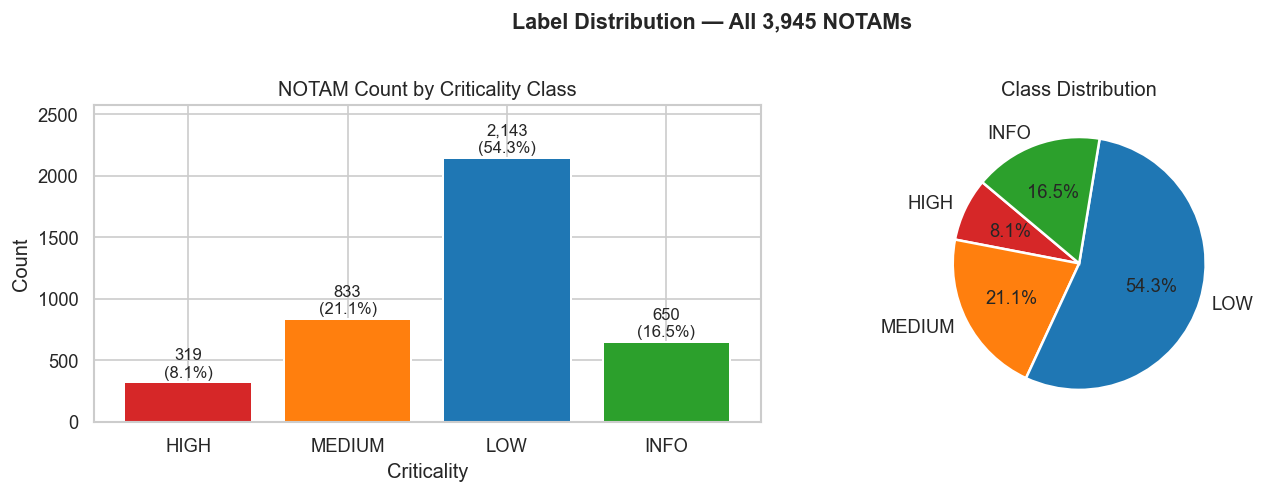

In [3]:
counts = df['criticality'].value_counts().reindex(CRITICALITY_LEVELS)
pcts   = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    counts.index,
    counts.values,
    color=[CRIT_COLORS[c] for c in counts.index],
    edgecolor='white',
    linewidth=1.2
)
for bar, count, pct in zip(bars, counts.values, pcts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('NOTAM Count by Criticality Class')
axes[0].set_xlabel('Criticality')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=[CRIT_COLORS[c] for c in counts.index],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Class Distribution')

plt.suptitle('Label Distribution — All 3,945 NOTAMs', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/figures/01_class_distribution.png', bbox_inches='tight')
plt.show()

print('\nClass imbalance ratio (LOW / HIGH):', round(counts['LOW'] / counts['HIGH'], 1))
print('-> We will use class_weight="balanced" in all classifiers to compensate.')

---
## Section 2 — Text Length Analysis

Do HIGH criticality NOTAMs tend to be shorter or longer? 
NOTAM format is terse by design — length differences can be a useful feature.

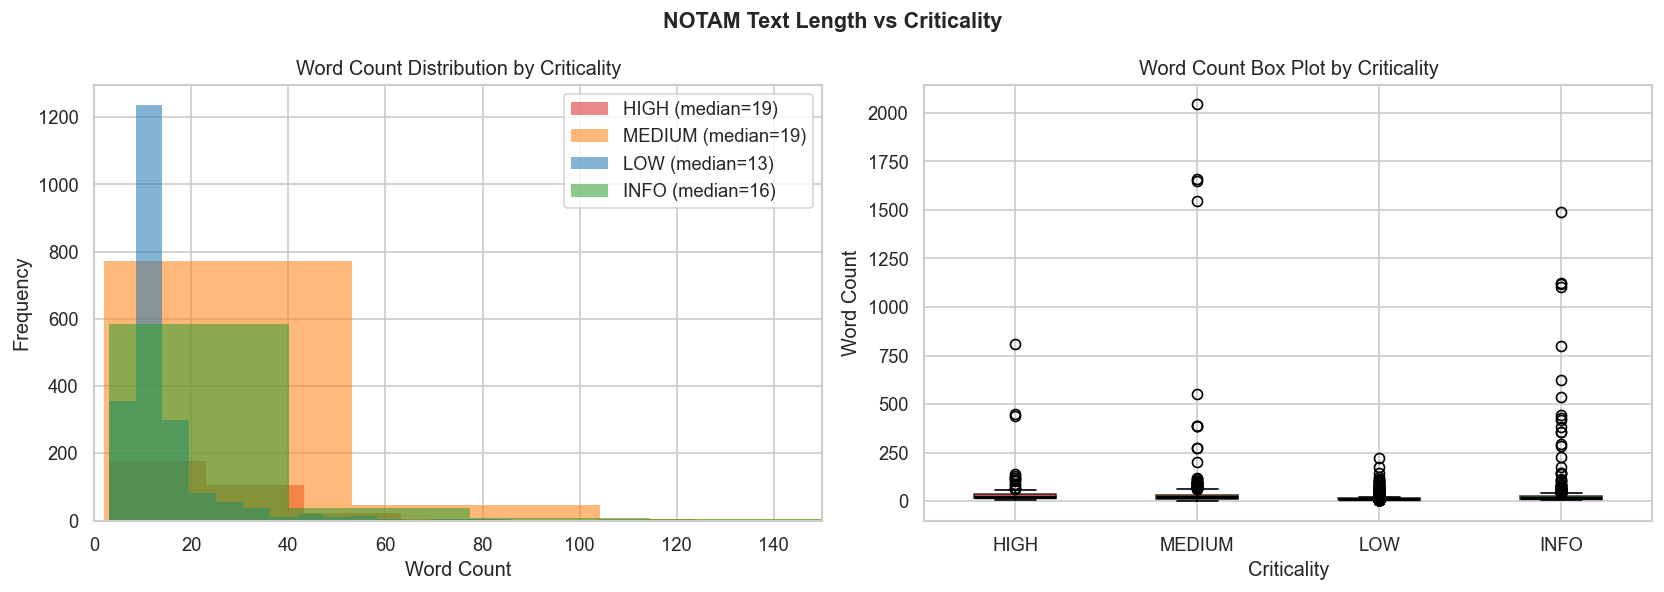

Median word counts by class:
criticality
HIGH      19.0
MEDIUM    19.0
LOW       13.0
INFO      16.0


In [5]:
df['word_count']  = df['text'].str.split().str.len()
df['char_count']  = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution per class
for crit in CRITICALITY_LEVELS:
    subset = df[df['criticality'] == crit]['word_count']
    axes[0].hist(
        subset, bins=40, alpha=0.55,
        label=f'{crit} (median={subset.median():.0f})',
        color=CRIT_COLORS[crit], edgecolor='none'
    )
axes[0].set_title('Word Count Distribution by Criticality')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 150)

# Box plot — easier to compare medians
data_by_class = [df[df['criticality'] == c]['word_count'].values for c in CRITICALITY_LEVELS]
bp = axes[1].boxplot(
    data_by_class,
    labels=CRITICALITY_LEVELS,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, crit in zip(bp['boxes'], CRITICALITY_LEVELS):
    patch.set_facecolor(CRIT_COLORS[crit])
    patch.set_alpha(0.7)
axes[1].set_title('Word Count Box Plot by Criticality')
axes[1].set_xlabel('Criticality')
axes[1].set_ylabel('Word Count')

plt.suptitle('NOTAM Text Length vs Criticality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/02_text_length.png', bbox_inches='tight')
plt.show()

print('Median word counts by class:')
print(df.groupby('criticality')['word_count'].median().to_string())

---
## Section 3 — Top Keywords per Class

What words are most associated with each criticality level?
This validates that the LLM labels are semantically meaningful
and previews what TF-IDF will learn in Layer 1.

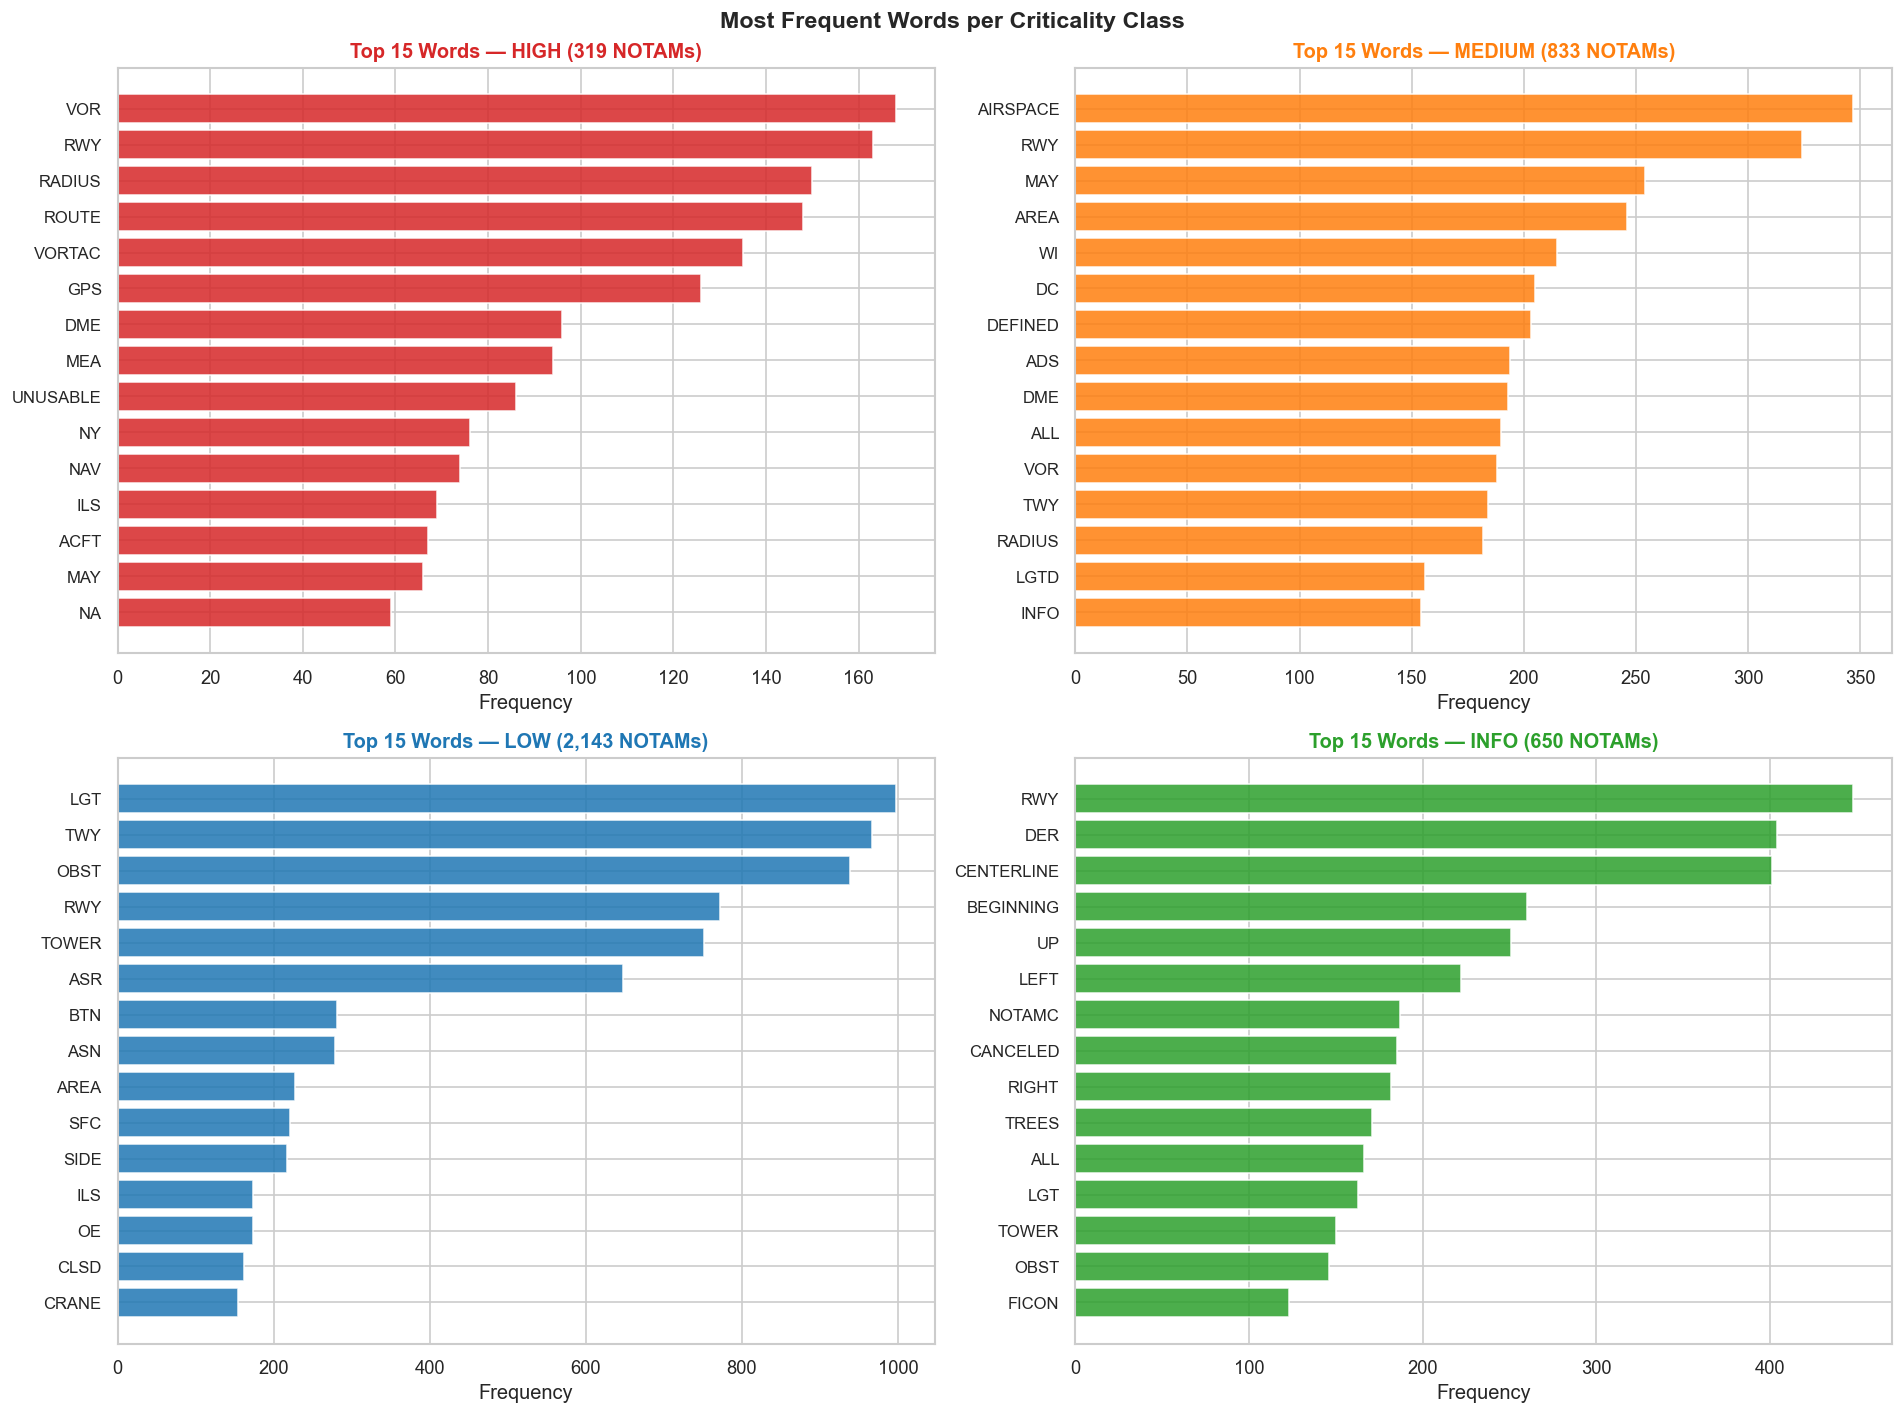

In [6]:
# Aviation stopwords — common words that carry no discriminative signal
AVIATION_STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'of', 'to', 'in', 'is', 'are',
    'at', 'on', 'for', 'not', 'with', 'from', 'by', 'be', 'as',
    'this', 'that', 'will', 'has', 'have', 'it', 'its', 'due',
    'via', 'per', 'ft', 'nm', 'agl', 'msl', 'est', 'utc',
}

def get_top_words(texts, n=15):
    words = []
    for text in texts:
        tokens = re.findall(r'\b[a-zA-Z]{2,}\b', str(text).upper())
        words.extend([t for t in tokens if t.lower() not in AVIATION_STOPWORDS])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, crit in enumerate(CRITICALITY_LEVELS):
    subset = df[df['criticality'] == crit]['text']
    top_words = get_top_words(subset, n=15)
    words, freqs = zip(*top_words)

    axes[idx].barh(
        list(reversed(words)),
        list(reversed(freqs)),
        color=CRIT_COLORS[crit],
        alpha=0.85,
        edgecolor='white'
    )
    axes[idx].set_title(f'Top 15 Words — {crit} ({len(subset):,} NOTAMs)',
                        fontweight='bold', color=CRIT_COLORS[crit])
    axes[idx].set_xlabel('Frequency')
    axes[idx].tick_params(axis='y', labelsize=10)

plt.suptitle('Most Frequent Words per Criticality Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/03_top_keywords.png', bbox_inches='tight')
plt.show()

---
## Section 4 — Classification Type vs Criticality

Does the FAA classification (DOM, FDC, INTL, MIL) predict criticality?
FDC NOTAMs should skew HIGH — this is a sanity check on label quality.

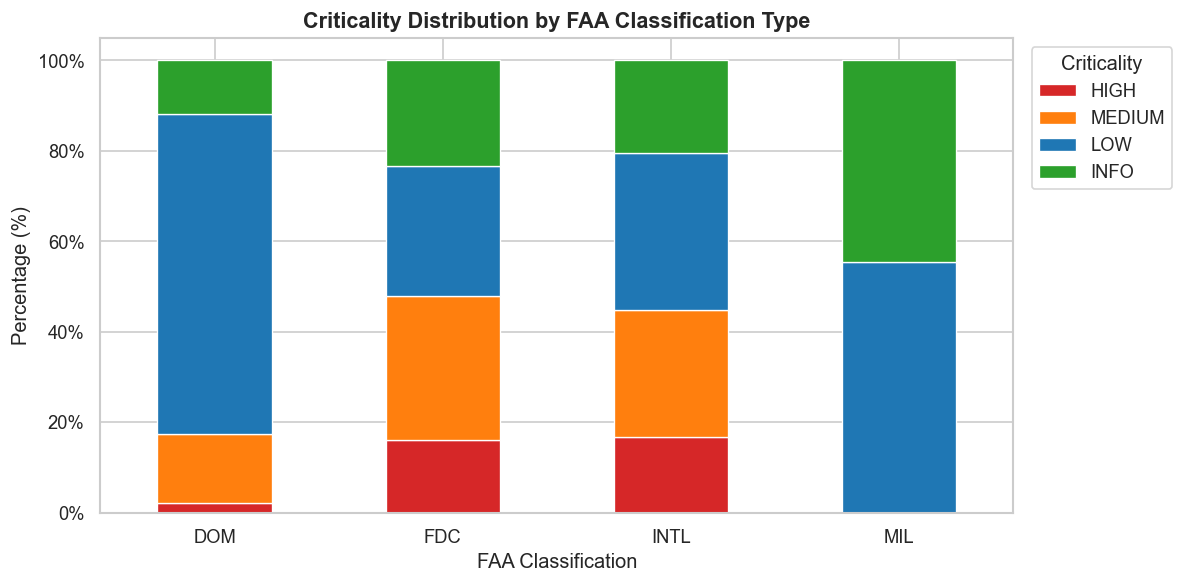

Raw counts:
criticality     HIGH  MEDIUM   LOW  INFO
classification                          
DOM               45     340  1572   266
FDC              104     206   186   151
INTL             170     287   354   208
MIL                0       0    31    25


In [7]:
# Crosstab: classification vs criticality (normalised by row)
ct = pd.crosstab(
    df['classification'],
    df['criticality'],
    normalize='index'
) * 100

# Reorder columns
ct = ct.reindex(columns=CRITICALITY_LEVELS, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(
    kind='bar',
    stacked=True,
    color=[CRIT_COLORS[c] for c in CRITICALITY_LEVELS],
    ax=ax,
    edgecolor='white',
    linewidth=0.8
)
ax.set_title('Criticality Distribution by FAA Classification Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('FAA Classification')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Criticality', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('../notebooks/figures/04_classification_vs_criticality.png', bbox_inches='tight')
plt.show()

print('Raw counts:')
print(pd.crosstab(df['classification'], df['criticality']))

---
## Section 5 — Score Distribution

The LLM assigned a continuous score (0-100) alongside each label.
Are scores well-separated between classes, or do they overlap significantly?
Overlap = harder classification problem.

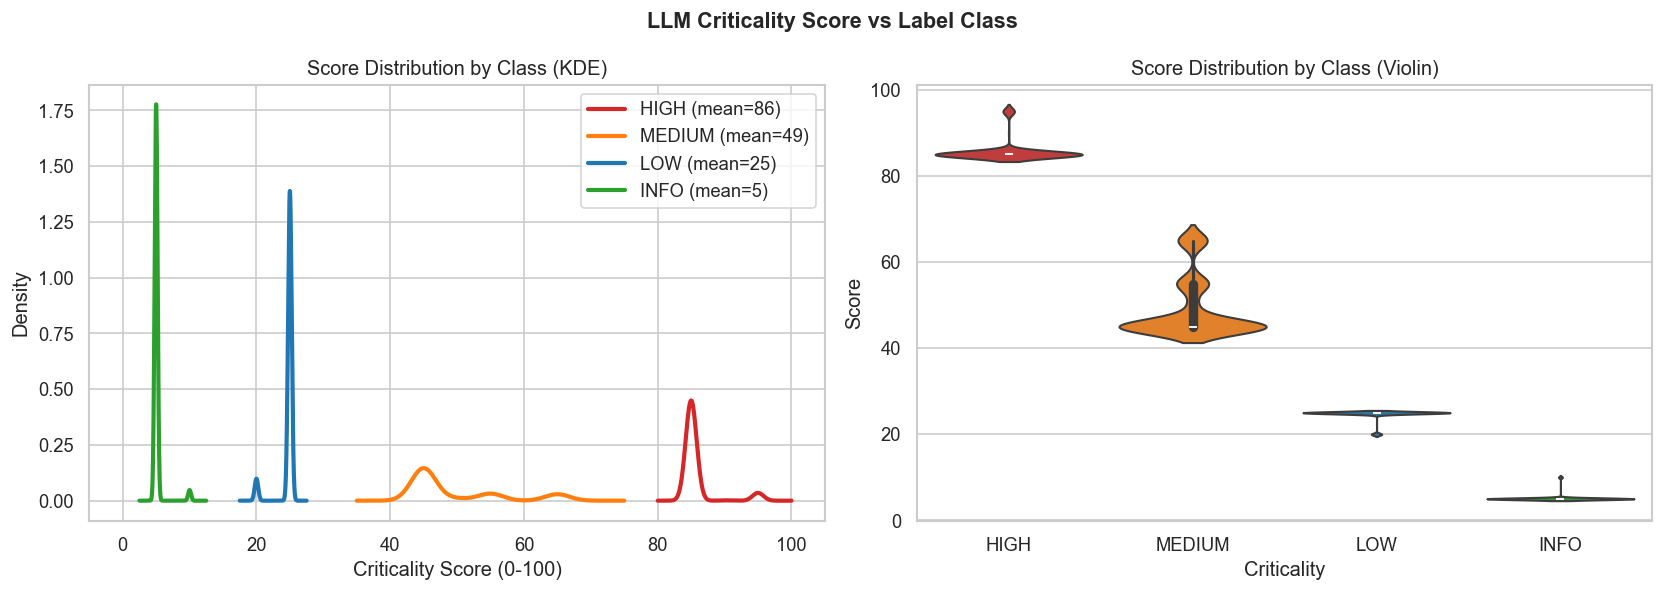

Mean scores by class:
criticality
HIGH      85.7
MEDIUM    49.4
LOW       24.7
INFO       5.1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot of score distributions
for crit in CRITICALITY_LEVELS:
    subset = df[df['criticality'] == crit]['score']
    subset.plot.kde(
        ax=axes[0],
        label=f'{crit} (mean={subset.mean():.0f})',
        color=CRIT_COLORS[crit],
        linewidth=2.5
    )
axes[0].set_title('Score Distribution by Class (KDE)')
axes[0].set_xlabel('Criticality Score (0-100)')
axes[0].set_xlim(-5, 105)
axes[0].legend()

# Violin plot
plot_data = pd.DataFrame({
    'Criticality': df['criticality'],
    'Score': df['score']
})
sns.violinplot(
    data=plot_data,
    x='Criticality',
    y='Score',
    order=CRITICALITY_LEVELS,
    palette=CRIT_COLORS,
    ax=axes[1],
    inner='box'
)
axes[1].set_title('Score Distribution by Class (Violin)')
axes[1].set_xlabel('Criticality')
axes[1].set_ylabel('Score')

plt.suptitle('LLM Criticality Score vs Label Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/05_score_distribution.png', bbox_inches='tight')
plt.show()

print('Mean scores by class:')
print(df.groupby('criticality')['score'].mean().round(1).to_string())

---
## Section 6 — Route Analysis

Does the flight route affect criticality distribution?
OKC->JFK is the longest route — does it have more HIGH NOTAMs?

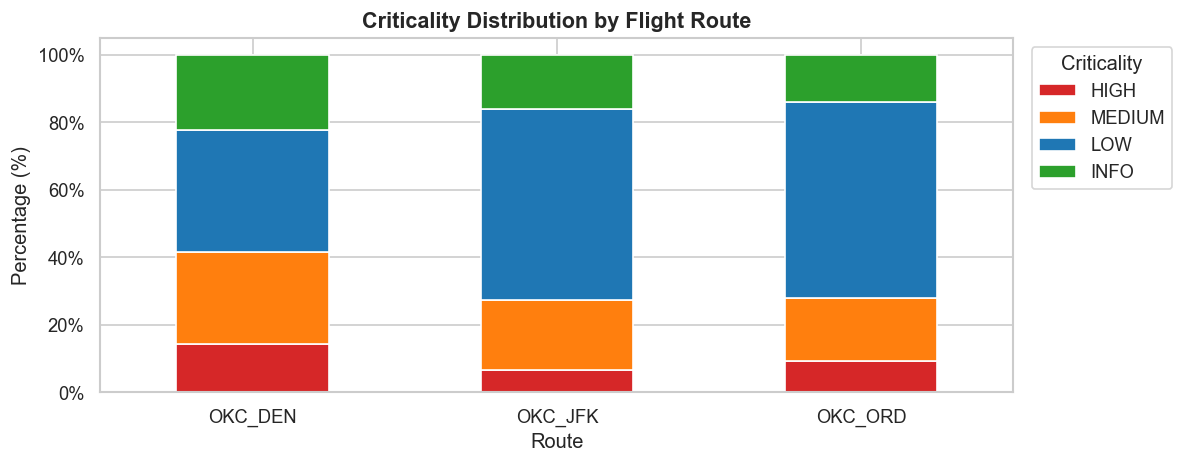


Raw counts by route:
criticality  HIGH  MEDIUM   LOW  INFO
route                                
OKC_DEN        69     133   175   108
OKC_JFK       171     539  1467   420
OKC_ORD        79     161   501   122


In [9]:
route_ct = pd.crosstab(
    df['route'],
    df['criticality'],
    normalize='index'
) * 100
route_ct = route_ct.reindex(columns=CRITICALITY_LEVELS, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
route_ct.plot(
    kind='bar',
    stacked=True,
    color=[CRIT_COLORS[c] for c in CRITICALITY_LEVELS],
    ax=ax,
    edgecolor='white'
)
ax.set_title('Criticality Distribution by Flight Route', fontsize=13, fontweight='bold')
ax.set_xlabel('Route')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Criticality', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('../notebooks/figures/06_route_vs_criticality.png', bbox_inches='tight')
plt.show()

print('\nRaw counts by route:')
print(pd.crosstab(df['route'], df['criticality']))

---
## Section 7 — Top Airports by Criticality

Which airports generate the most HIGH criticality NOTAMs?
This is the kind of insight a real dispatcher would care about.

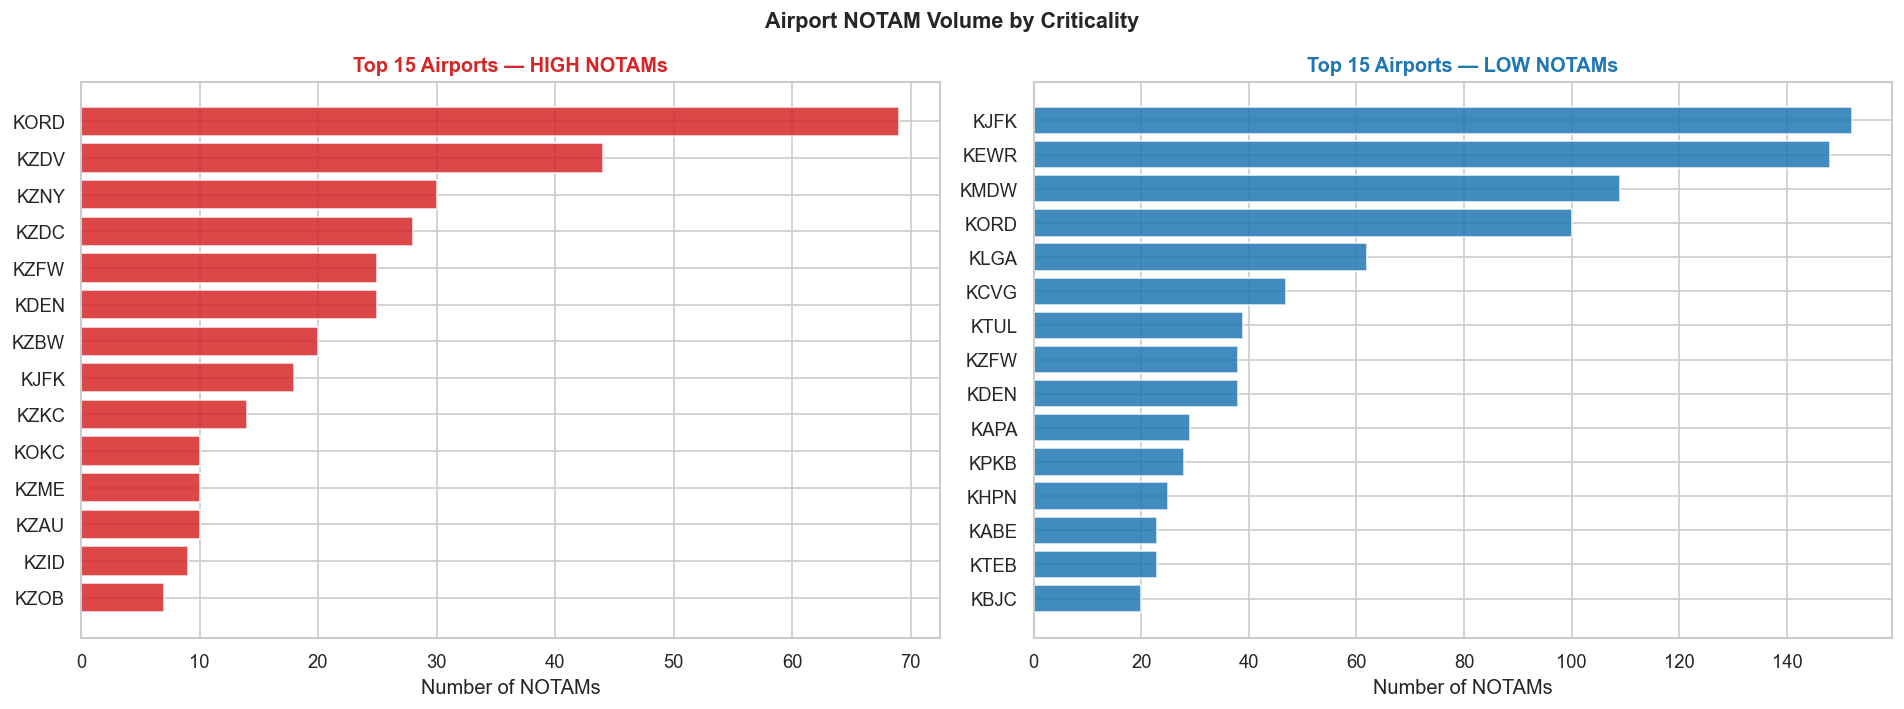

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, crit, color in [
    (axes[0], 'HIGH',   CRIT_COLORS['HIGH']),
    (axes[1], 'LOW',    CRIT_COLORS['LOW']),
]:
    subset = (
        df[(df['criticality'] == crit) & (df['icao_location'] != 'None')]
        ['icao_location']
        .value_counts()
        .head(15)
    )
    ax.barh(
        list(reversed(subset.index)),
        list(reversed(subset.values)),
        color=color, alpha=0.85, edgecolor='white'
    )
    ax.set_title(f'Top 15 Airports — {crit} NOTAMs',
                 fontweight='bold', color=color)
    ax.set_xlabel('Number of NOTAMs')

plt.suptitle('Airport NOTAM Volume by Criticality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/07_airports_by_criticality.png', bbox_inches='tight')
plt.show()

---
## Section 8 — Selection Code Analysis

Q-codes (selection codes) are the FAA's own categorisation system.
59% of our NOTAMs have no Q-code — this plot shows how useful
they are when they ARE present.

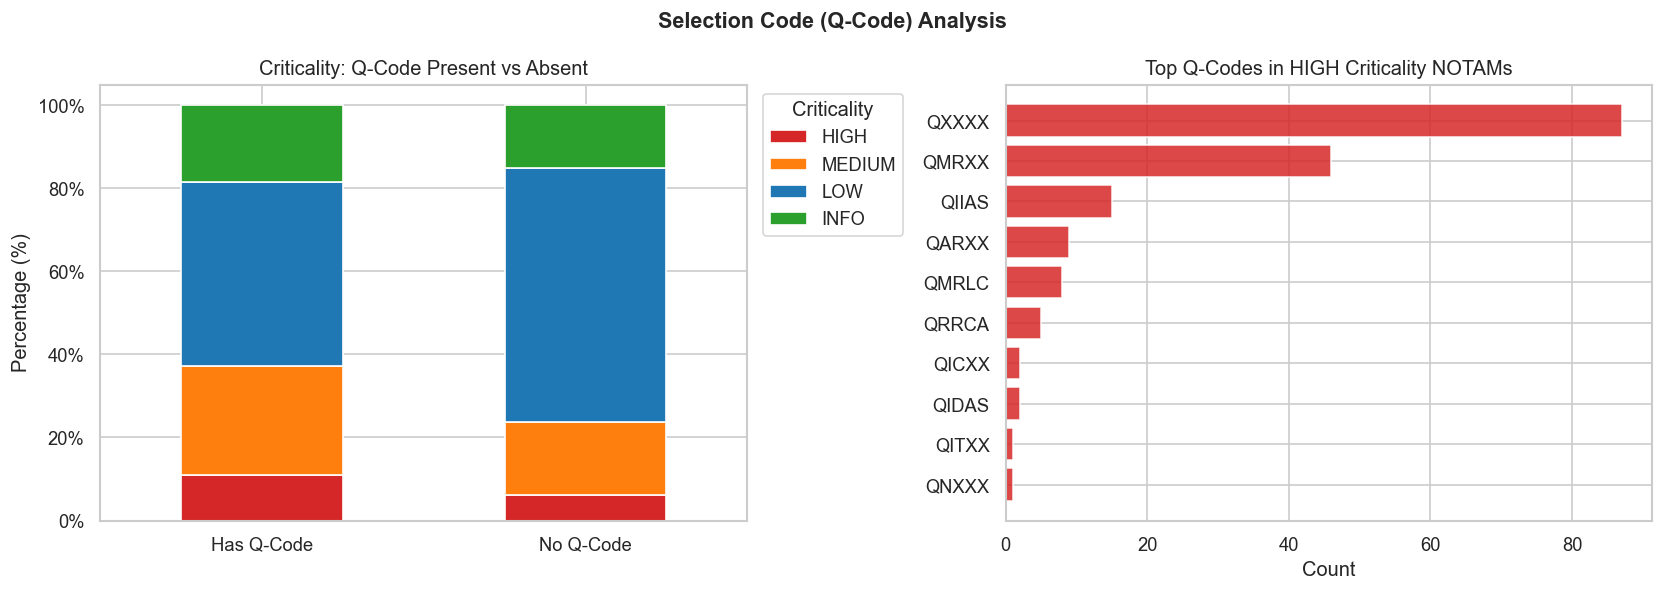

NOTAMs with Q-code:    1,609
NOTAMs without Q-code: 2,336


In [11]:
# NOTAMs with a selection code vs without
df['has_selection_code'] = df['selection_code'].apply(
    lambda x: 'Has Q-Code' if (pd.notna(x) and str(x) not in ('None', '')) else 'No Q-Code'
)

sc_ct = pd.crosstab(
    df['has_selection_code'],
    df['criticality'],
    normalize='index'
) * 100
sc_ct = sc_ct.reindex(columns=CRITICALITY_LEVELS, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: does having a Q-code correlate with criticality?
sc_ct.plot(
    kind='bar',
    stacked=True,
    color=[CRIT_COLORS[c] for c in CRITICALITY_LEVELS],
    ax=axes[0],
    edgecolor='white'
)
axes[0].set_title('Criticality: Q-Code Present vs Absent')
axes[0].set_xlabel('')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Criticality', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# Top Q-codes that appear in HIGH criticality NOTAMs
high_codes = (
    df[(df['criticality'] == 'HIGH') &
       (df['selection_code'].notna()) &
       (~df['selection_code'].isin(['None', '']))]
    ['selection_code']
    .value_counts()
    .head(10)
)
if len(high_codes) > 0:
    axes[1].barh(
        list(reversed(high_codes.index)),
        list(reversed(high_codes.values)),
        color=CRIT_COLORS['HIGH'], alpha=0.85, edgecolor='white'
    )
    axes[1].set_title('Top Q-Codes in HIGH Criticality NOTAMs')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No Q-codes found in HIGH class',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Selection Code (Q-Code) Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/08_selection_codes.png', bbox_inches='tight')
plt.show()

print(f"NOTAMs with Q-code:    {(df['has_selection_code'] == 'Has Q-Code').sum():,}")
print(f"NOTAMs without Q-code: {(df['has_selection_code'] == 'No Q-Code').sum():,}")

---
## Checkpoint 2.2 — Key Insights

Fill these in after running all sections above.
These become your talking points in interviews.

In [ ]:
print('=' * 65)
print('  EDA SUMMARY — KEY FINDINGS')
print('=' * 65)

total = len(df)
high_pct  = (df['criticality'] == 'HIGH').sum()   / total * 100
low_pct   = (df['criticality'] == 'LOW').sum()    / total * 100
no_qcode  = (df['has_selection_code'] == 'No Q-Code').sum() / total * 100

high_med_wc  = df[df['criticality'] == 'HIGH']['word_count'].median()
low_med_wc   = df[df['criticality'] == 'LOW']['word_count'].median()
info_med_wc  = df[df['criticality'] == 'INFO']['word_count'].median()

imbalance_ratio = (df['criticality'] == 'LOW').sum() / (df['criticality'] == 'HIGH').sum()

print(f"""
1. CLASS IMBALANCE
   LOW dominates at {low_pct:.1f}% vs HIGH at {high_pct:.1f}%.
   Imbalance ratio: {imbalance_ratio:.1f}x.
   -> Will use class_weight='balanced' in all classifiers.

2. TEXT LENGTH
   HIGH NOTAMs median word count:  {high_med_wc:.0f} words
   LOW NOTAMs median word count:   {low_med_wc:.0f} words  
   INFO NOTAMs median word count:  {info_med_wc:.0f} words
   -> Word count alone is a weak signal but may help at the margins.

3. MISSING Q-CODES
   {no_qcode:.1f}% of NOTAMs have no selection code (Q-code).
   -> Rule-based systems fail on 60% of this dataset.
   -> Text-based ML is necessary, not optional.

4. FDC CLASSIFICATION
   FDC NOTAMs should skew HIGH — check Section 4 plot to confirm.
   If FDC skews LOW, the system prompt may need adjustment.

5. ROUTE DIVERSITY
   Three routes provide geographic diversity across the US.
   OKC->JFK covers the most airspace and has the most NOTAMs.
""")
print('=' * 65)

  EDA SUMMARY — KEY FINDINGS

1. CLASS IMBALANCE
   LOW dominates at 54.3% vs HIGH at 8.1%.
   Imbalance ratio: 6.7x.
   -> Will use class_weight='balanced' in all classifiers.

2. TEXT LENGTH
   HIGH NOTAMs median word count:  19 words
   LOW NOTAMs median word count:   13 words  
   INFO NOTAMs median word count:  16 words
   -> Word count alone is a weak signal but may help at the margins.

3. MISSING Q-CODES
   59.2% of NOTAMs have no selection code (Q-code).
   -> Rule-based systems fail on 60% of this dataset.
   -> Text-based ML is necessary, not optional.

4. FDC CLASSIFICATION
   FDC NOTAMs should skew HIGH — check Section 4 plot to confirm.
   If FDC skews LOW, the system prompt may need adjustment.

5. ROUTE DIVERSITY
   Three routes provide geographic diversity across the US.
   OKC->JFK covers the most airspace and has the most NOTAMs.

Checkpoint 2.2 complete. Proceed to 03_model_training.ipynb
